# 🚀 미니프로젝트 1 — 분류: MNIST·Fashion-MNIST를 CNN으로 + Streamlit 배포 💡

**여러분의 과제 시간입니다.** 1~10강에서 배운 것만으로 이미지 분류기를 만들고, validation으로 손잡이를 탐색한 뒤, 마지막에 test를 딱 한 번 열어 최종 성능을 확인합니다. 완성 모델은 웹앱으로 배포해 **우리 반 리더보드**에서 서로의 기록을 비교합니다.

| 구분 | 내용 | 제출물 |
|---|---|---|
| **1차 (필수)** | MNIST CNN — 전처리·훈련·**validation 실험 3개 이상**·최종 test 1회 | 이 노트북 |
| **2차 (필수)** | 같은 코드로 Fashion-MNIST — 별도 validation + 오답 확인 | 이 노트북 |
| **3차 (필수)** | 분류 앱 핵심 TODO 4개 완성 + Streamlit 연결 | 통합 showcase URL |
| 🏆 **리더보드 (필수)** | validation으로 고른 모델의 최종 test 기록 공유 | 제출 양식 1행 |
| 🏅 **도전 (선택)** | CIFAR-10 — 컬러 3채널로 확장 | 이 노트북 |

> **선수지식**: 3강(첫 신경망)·8강(학습 루프)·9강(일반화)·10강(분류 심화)이면 충분합니다. CNN 층의 설계 원리는 12강에서 배웁니다.
>
> **시험지 봉인 규칙**: 모델과 설정은 validation 결과로 고릅니다. test를 본 뒤 설정을 바꾸면 그 test도 사실상 validation이 되므로, 최종 test는 모델 선택이 끝난 뒤 1회만 사용합니다.

> ✍️ **직접 입력** 표시가 있는 줄은 바로 위 주석의 코드를 보고 직접 타이핑해 완성합니다.

**평가 기준** — ① TODO·✍️ 전부 완성 + 실행 결과 ② validation 실험 **3개 이상**과 기록 ③ 최종 test 1회 ④ 앱 핵심 TODO 4개 완성 ⑤ 통합 showcase 연결 ⑥ 리더보드 제출 1행


## 🔑 이 과제의 핵심 스캐폴딩 — 처음 만나는 함수들

| 함수/클래스 | 역할 | 등장 |
|---|---|---|
| `nn.Conv2d(입력채널, 출력채널, kernel_size)` | 작은 필터로 이미지의 지역 패턴 탐색 | [Step 3] |
| `nn.MaxPool2d(2)` | 2×2 구역의 최대값만 남겨 절반 크기로 요약 | [Step 3] |
| `nn.Flatten()` | `(N, 채널, 높이, 너비)` → `(N, 한 줄)`로 펴서 Linear에 연결 | [Step 3] |
| `torch.save(체크포인트, 경로)` | 가중치·구조 설정·성능 지표를 함께 저장 | [Step 7] |
| `keras.datasets.fashion_mnist` | MNIST와 같은 형식의 의류 이미지 | [Step 8] |

> **📐 이 과제의 계약 6줄**
> 1. 입력: `(N, 1, 28, 28)` float32, 값 0~1
> 2. 원래 train 60,000장을 **fit 50,000 + validation 10,000**으로 분리
> 3. 모델 출력: 로짓 `(N, 10)` — softmax 없음
> 4. 정답: 정수 라벨 `(N,)`, dtype `long`
> 5. 손실: `nn.CrossEntropyLoss()(로짓, 정수라벨)`
> 6. 모델 선택은 validation, 최종 보고만 test 10,000장


In [ ]:
# ── 실행 준비 (로컬 · Colab · Kaggle 어디서나) ──
# [왜] 이 과제에 필요한 라이브러리를 환경에 맞게 준비하고, 연산 장치(device)를 자동 선택합니다.
# [연결] 이 셀의 device 로직은 1강 Solo에서 여러분이 직접 만든 '내 환경 설정'의 자동 감지 버전입니다.
import sys, os, importlib.util

# 1) 실행 환경 감지
if 'google.colab' in sys.modules:      ENV = "Colab"
elif os.path.exists('/kaggle/input'):  ENV = "Kaggle"
else:                                  ENV = "로컬"

# 2) 이 과제가 쓰는 라이브러리 점검 (없으면 설치 안내)
NEED = [("torch","torch"), ("keras","keras"), ("matplotlib","matplotlib")]
missing = [pip for imp, pip in NEED if importlib.util.find_spec(imp.split(".")[0]) is None]
if missing:
    bang = "" if ENV == "로컬" else "!"
    print(f"[{ENV}] 아래를 실행해 설치하세요:  {bang}pip install " + " ".join(missing))
else:
    print(f"[{ENV}] 라이브러리 준비 완료")

# 3) 연산 장치 자동 선택 (Apple MPS > NVIDIA CUDA > CPU)
import torch
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE = {DEVICE}")

# 4) 한글 그래프 폰트 (OS 자동 — 그래프 제목·라벨 깨짐 방지)
import matplotlib.pyplot as plt, platform
import matplotlib.font_manager as fm
if platform.system() == "Darwin":      plt.rcParams['font.family'] = ['AppleGothic', 'DejaVu Sans']
elif platform.system() == "Windows":   plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
else:                                  # 리눅스(Colab·Kaggle): 나눔고딕이 없으면 설치 후 즉시 등록
    if not any(f.name == 'NanumGothic' for f in fm.fontManager.ttflist):
        os.system("apt-get -qq -y install fonts-nanum > /dev/null 2>&1")   # Colab 기본 이미지엔 한글 폰트가 없음
        for _fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
            fm.fontManager.addfont(_fp)                                    # 설치한 폰트를 재시작 없이 등록
    plt.rcParams['font.family'] = ['NanumGothic', 'DejaVu Sans']   # 리스트 = 폴백 체인(기호는 DejaVu 보완)
plt.rcParams['axes.unicode_minus'] = False

[Colab] 라이브러리 준비 완료
DEVICE = cpu


## 1차 과제 (필수) — MNIST를 CNN으로

3강에서 Dense(Linear)만으로 97~98%를 얻었습니다. **같은 문제를 CNN으로 풀면 얼마나 오를까요?** 직접 확인합니다.

진행 순서: [Step 1] 데이터 로드 → [Step 2] 전처리(TODO) → [Step 3] CNN 모델(제공) → [Step 4] 훈련 루프(TODO) → [Step 5] 평가 → [Step 6] **손잡이 탐색 실험**(TODO) → [Step 7] 저장

In [5]:
# [Step 1] MNIST 로드 — 3강과 동일한 keras 직접 호출 (제공)
import os
os.environ.setdefault("KERAS_BACKEND", "torch")   # tensorflow 없이 keras만 설치돼 있어도 동작
import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(f"훈련: {x_train.shape}, 테스트: {x_test.shape}")   # (60000, 28, 28) / (10000, 28, 28)
print(f"픽셀 값 범위: {x_train.min()} ~ {x_train.max()}")  # 0 ~ 255 정수

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
훈련: (60000, 28, 28), 테스트: (10000, 28, 28)
픽셀 값 범위: 0 ~ 255


shape : (60000, 28, 28) · dtype: uint8
값 범위: 0 ~ 255
클래스 분포: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


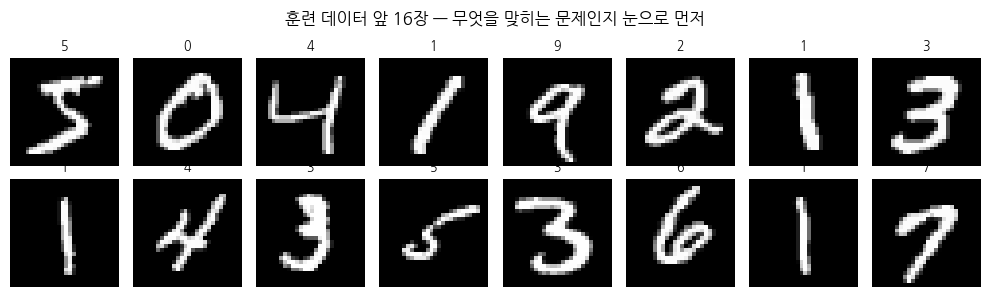

In [6]:
# [Step 1.5] 데이터 확인(EDA) — 학습 전에 데이터부터 본다 (제공)
# 어떤 데이터인지 모르고 모델부터 돌리는 것은 문제를 안 읽고 답부터 쓰는 것과 같습니다.
import numpy as np

print("shape :", x_train.shape, "· dtype:", x_train.dtype)     # (60000, 28, 28) uint8 — 아직 전처리 전
print("값 범위:", x_train.min(), "~", x_train.max())            # 0(검정) ~ 255(흰색)
cls, cnt = np.unique(y_train, return_counts=True)
print("클래스 분포:", dict(zip(cls.tolist(), cnt.tolist())))     # 0~9가 대략 6천 장씩 — 거의 균형
# ↑ 클래스가 균형이므로 '정확도'가 공정한 성적표가 됩니다 (한쪽으로 쏠린 데이터라면 정확도만 봐선 안 됩니다 — 9강 참조)

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for k, ax in enumerate(axes.flat):
    ax.imshow(x_train[k], cmap="gray")
    ax.set_title(int(y_train[k]), fontsize=9); ax.axis("off")
plt.suptitle("훈련 데이터 앞 16장 — 무엇을 맞히는 문제인지 눈으로 먼저")
plt.tight_layout(); plt.show()

In [7]:
# [Step 2] TODO ① — CNN 입력 형태로 전처리하고 validation을 분리하세요.
# 힌트 1: CNN 입력은 (N, 1, 28, 28), dtype float32, 값 범위 0~1입니다.
# 힌트 2: 원래 train 60,000장 안에서 50,000장은 fit, 10,000장은 validation으로 씁니다.
#         test 10,000장은 [Step 7] 전까지 봉인합니다.

# x_train 전처리: 모양 변경 -> 타입 변경 -> 0~1 정규화
x_train = x_train.reshape(-1, 1, 28, 28).astype("float32") / 255.0

# x_test 전처리: train과 똑같은 규칙으로 처리 (봉인해 두지만 형태는 맞춰야 함)
x_test  = x_test.reshape(-1, 1, 28, 28).astype("float32") / 255.0


assert x_train.shape == (60000, 1, 28, 28), f"shape가 다릅니다: {x_train.shape}"
assert str(x_train.dtype) == "float32" and x_train.max() <= 1.0, "dtype 또는 값 범위를 확인하세요"

split_idx = np.random.default_rng(0).permutation(len(x_train))
fit_idx, val_idx = split_idx[:-10000], split_idx[-10000:]
x_fit, y_fit = x_train[fit_idx], y_train[fit_idx]
x_val, y_val = x_train[val_idx], y_train[val_idx]
print(f"✅ 전처리·분할 통과: fit {x_fit.shape} / validation {x_val.shape} / test {x_test.shape} (봉인)")


✅ 전처리·분할 통과: fit (50000, 1, 28, 28) / validation (10000, 1, 28, 28) / test (10000, 1, 28, 28) (봉인)


### CNN 모델 — 완성품으로 제공합니다 (단, 손잡이 4개는 여러분 것)

아직 Conv2d의 원리를 배우지 않았으므로(12강), 지금은 **데이터가 흘러가는 shape**만 따라가면 충분합니다:

```
(N, 1, 28, 28) ──Conv2d(1→32)──▶ (N, 32, 28, 28)   32개 필터로 패턴 탐색
              ──MaxPool2d(2)──▶ (N, 32, 14, 14)   절반 크기로 요약
              ──Conv2d(32→64)─▶ (N, 64, 14, 14)   더 복잡한 패턴 64종
              ──MaxPool2d(2)──▶ (N, 64,  7,  7)   다시 절반
              ──Flatten───────▶ (N, 3136)          여기서부터는 3강과 같은 Dense
              ──Linear·Dropout▶ (N, 10)            클래스별 로짓 (softmax 없음)
```

구조는 고정이지만 **크기를 정하는 숫자 4개(`conv1`·`conv2`·`hidden`·`dropout`)는 인자로 열어 두었습니다** — [Step 6]에서 이 손잡이들을 돌려 성능을 탐색하는 것이 이 과제의 본론입니다.

In [8]:
# [Step 3] CNN 모델 (제공) — 설계 원리는 12강에서. 크기 손잡이 4개만 인자로 열어 두었습니다.
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, conv1=32, conv2=64, hidden=128, dropout=0.3):
        super().__init__()
        # 특징 추출부 — 이미지의 '지역 패턴'(획·모서리)을 찾아내는 층들
        self.features = nn.Sequential(
            # ✍️ 직접 입력 1 — 첫 합성곱 층: 3×3 필터 conv1개로 지역 패턴을 훑습니다 (28×28 유지)
            # nn.Conv2d(1, conv1, kernel_size=3, padding=1),
            nn.Conv2d(1, conv1, kernel_size=3, padding=1),      # ← ...을 지우고 위 주석의 코드를 직접 타이핑
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # → 14×14
            nn.Conv2d(conv1, conv2, kernel_size=3, padding=1),   # 더 복잡한 패턴 conv2종
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # → 7×7
        )
        # 분류부 — 뽑아낸 특징을 3강과 같은 Dense(Linear)로 10개 클래스 점수화
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # (N, conv2, 7, 7) → (N, conv2*49)
            nn.Linear(conv2 * 7 * 7, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),                 # 9강의 과대적합 방지 장치
            # ✍️ 직접 입력 2 — 출력층: 클래스별 로짓 10개 (softmax 없음 — 7강 계약)
            nn.Linear(hidden, 10),               # ← ...을 지우고 위 주석의 코드를 직접 타이핑                                                             
        )
    def forward(self, x):
        return self.classifier(self.features(x))

torch.manual_seed(0)                             # 재현성 — 결과 비교를 위해 시드 고정
model = CNN().to(DEVICE)                         # 기본값: conv1=32, conv2=64, hidden=128, dropout=0.3
n_params = sum(p.numel() for p in model.parameters())
print(f"파라미터 수: {n_params:,}")               # 3강 Dense(hidden=128) 약 10만 개와 비교해보세요

파라미터 수: 421,642


In [9]:
# [Step 4] TODO ② — fit 조각으로 훈련 루프를 완성하세요 (8강의 5단계 그대로).
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

xt = torch.tensor(x_fit, device=DEVICE)
yt = torch.tensor(y_fit, dtype=torch.long, device=DEVICE)

EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(xt))
    for i in range(0, len(xt), 128):
        idx = perm[i:i+128]
        # TODO ②: ① gradient 초기화 ② 순전파 ③ 손실 ④ 역전파 ⑤ 업데이트
         # 1) gradient 초기화
        optimizer.zero_grad()
        
        # 2) 순전파 (배치 크기만큼 예측값 추출)
        logits = model(xt[idx])
        
        # 3) 손실 계산 (예측값과 해당 배치의 실제 정답 비교)
        loss = loss_fn(logits, yt[idx])
        
        # 4) 역전파 (기울기 계산)
        loss.backward()
        
        # 5) 업데이트 (가중치 수정)
        optimizer.step()
        
    print(f"epoch {epoch+1}/{EPOCHS} 마지막 배치 loss: {loss.item():.4f}")


epoch 1/3 마지막 배치 loss: 0.1022
epoch 2/3 마지막 배치 loss: 0.0606
epoch 3/3 마지막 배치 loss: 0.1325


In [ ]:
# [Step 5] validation 평가 — 지금은 test가 아니라 validation으로 설정을 비교합니다.
model.eval()
with torch.no_grad():
    xb = torch.tensor(x_val, device=DEVICE)
    yb = torch.tensor(y_val, dtype=torch.long, device=DEVICE)
    # ✍️ 직접 입력 3 — validation 정확도
    # val_acc = (model(xb).argmax(1) == yb).float().mean().item()
    val_acc = (model(xb).argmax(1) == yb).float().mean().item()
print(f"CNN validation 정확도: {val_acc:.4f}")

DENSE_VAL_ACC = None  # TODO ③: 같은 validation 분할로 측정한 Dense 정확도가 있을 때만 적으세요.
if DENSE_VAL_ACC:
    print(f"Dense 대비: {DENSE_VAL_ACC:.4f} → {val_acc:.4f} ({(val_acc-DENSE_VAL_ACC)*100:+.2f}%p)")


CNN validation 정확도: 0.9864


### [Step 6] 손잡이 탐색 실험 (TODO ④) — validation으로 최소 3개

| 손잡이 | 기본값 | 예상 변화 |
|---|---|---|
| `conv1` / `conv2` | 32 / 64 | ↑ 더 많은 패턴 탐지, 파라미터·시간 증가 |
| `hidden` | 128 | ↑ 분류부 용량 증가, 과대적합 위험도 증가 |
| `dropout` | 0.3 | ↑ 규제 강화, 과하면 학습 방해 |
| `lr` | 1e-3 | ↑ 빠르지만 불안정, ↓ 안정적이지만 느림 |
| `epochs` | 3 | ↑ 더 오래 학습 — **validation 추세**로 판단 |
| `batch` | 128 | 기울기의 표본 크기 변화 |

**탐색 규칙**
1. 한 번에 하나만 바꿉니다.
2. validation 결과를 보고 다음 수를 정합니다.
3. 실패한 실험도 기록합니다.
4. 이 단계에서는 `x_test`, `y_test`를 함수에 넣지 않습니다.

| 실험 | 바꾼 것 | 가설 | validation 정확도 | 파라미터 수 | 다음 수 |
|---|---|---|---|---|---|
| 기준 | 전부 기본값 | — | (내 결과) | 421,642 | |
| 1 | epochs=8 |더 오래 학습하면 상승할 것 | (실행 결과 입력) | 421,642 | 드롭아웃 조정 시도 |
| 2 | dropout=0.5 | 규제를 주면 과적합이 막힐 것 | (실행 결과 입력) | 421,642 | 학습률 미세 조정 시도 |
| 3 | lr=5e-4, epochs=8 | 느리지만 안정적으로 고점 도달 | (실행 결과 입력) | 421,642 | 가장 좋은 모델 확정 |


In [ ]:
# [Step 6 도구] run_cnn — fit으로 학습하고 validation으로 비교합니다.
# 반환값: (모델, validation 정확도, 에폭별 평균 train loss)
import time

def run_cnn(x_tr, y_tr, x_va, y_va, conv1=32, conv2=64, hidden=128,
            dropout=0.3, lr=1e-3, epochs=3, batch=128, seed=0):
    torch.manual_seed(seed)
    m = CNN(conv1, conv2, hidden, dropout).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    xt_ = torch.tensor(x_tr, device=DEVICE)
    yt_ = torch.tensor(y_tr, dtype=torch.long, device=DEVICE)
    t0, losses = time.time(), []
    for ep in range(epochs):
        m.train()
        perm = torch.randperm(len(xt_))
        ep_loss, n_b = 0.0, 0
        for i in range(0, len(xt_), batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = loss_fn(m(xt_[idx]), yt_[idx])
            loss.backward()
            opt.step()
            ep_loss += loss.item(); n_b += 1
        losses.append(ep_loss / n_b)
    m.eval()
    with torch.no_grad():
        xb_ = torch.tensor(x_va, device=DEVICE)
        yb_ = torch.tensor(y_va, dtype=torch.long, device=DEVICE)
        val_acc_ = (m(xb_).argmax(1) == yb_).float().mean().item()
    n = sum(p.numel() for p in m.parameters())
    print(f"val acc {val_acc_:.4f} · 마지막 loss {losses[-1]:.4f} · 파라미터 {n:,} · {time.time()-t0:.0f}초"
          f"  ← conv {conv1}/{conv2} · hidden {hidden} · dropout {dropout} · lr {lr} · epochs {epochs} · batch {batch}")
    return m, val_acc_, losses

# TODO ④ — validation으로 최소 3번 실험합니다. test는 넣지 않습니다.
# [실험 1] 가설: 에포크를 3에서 8로 늘려 더 오래 학습시키면 정확도가 오를 것이다.
candidate1, val1, losses1 = run_cnn(x_fit, y_fit, x_val, y_val, epochs=8)

# [실험 2] 가설: 규제(Dropout)를 0.3에서 0.5로 강하게 걸면 과적합이 방지되어 성능이 오를 것이다.
candidate2, val2, losses2 = run_cnn(x_fit, y_fit, x_val, y_val, dropout=0.5, epochs=3)

# [실험 3] 가설: 학습률(lr)을 조금 더 미세하게 조정(1e-3 -> 5e-4)하고 에포크를 늘리면 안정적으로 고점에 도달할 것이다.
candidate3, val3, losses3 = run_cnn(x_fit, y_fit, x_val, y_val, lr=5e-4, epochs=8)
# 🎯 통과선: validation 0.9850 이상 — 손잡이(epochs 등)를 바꿔가며 직접 확인해 보세요


KeyboardInterrupt: 

In [9]:
# [Step 7] validation 최고 모델을 확정한 뒤 test를 딱 한 번 평가하고 체크포인트를 저장합니다.
# 아래 네 줄을 내 최고 실험의 반환값·설정으로 바꾸세요. 기본 모델을 고르면 그대로 둡니다.
best_model = candidate1
BEST_VAL_ACC = val1
BEST_LOSSES = losses1
BEST_CONFIG = {"conv1": 32, "conv2": 64, "hidden": 128, "dropout": 0.3,
               "epochs": 8, "lr": 1e-3, "batch": 128}  # epochs를 8로 변경

best_model.eval()
with torch.no_grad():
    test_pred = best_model(torch.tensor(x_test, device=DEVICE)).argmax(1)
    FINAL_TEST_ACC = (test_pred == torch.tensor(y_test, dtype=torch.long, device=DEVICE)).float().mean().item()

from pathlib import Path
app_dir = Path("과제_Streamlit_앱_분류")
app_dir.mkdir(exist_ok=True)
checkpoint = {
    "state_dict": best_model.state_dict(),
    "model_config": {k: BEST_CONFIG[k] for k in ["conv1", "conv2", "hidden", "dropout"]},
    "training_config": {k: BEST_CONFIG[k] for k in ["epochs", "lr", "batch"]},
    "metrics": {"val_acc": BEST_VAL_ACC, "test_acc": FINAL_TEST_ACC},
    "n_params": sum(p.numel() for p in best_model.parameters()),
}
torch.save(checkpoint, app_dir / "mnist_cnn.pt")
print(f"최종 확정: validation {BEST_VAL_ACC:.4f} · test {FINAL_TEST_ACC:.4f} (test는 이 1회만)")
print(f"저장 완료: {app_dir / 'mnist_cnn.pt'}")
# ⚠️ test 결과를 본 뒤 설정을 다시 바꾸면 test가 봉인된 시험지가 아니게 됩니다.


최종 확정: validation 0.9882 · test 0.9883 (test는 이 1회만)
저장 완료: 과제_Streamlit_앱_분류/mnist_cnn.pt


In [10]:
import os
print(os.path.exists("과제_Streamlit_앱_분류/mnist_cnn.pt"))

True


In [11]:
import os
print("현재 노트북이 인식한 실제 저장 경로:")
print(os.path.abspath("과제_Streamlit_앱_분류/mnist_cnn.pt"))

현재 노트북이 인식한 실제 저장 경로:
/content/과제_Streamlit_앱_분류/mnist_cnn.pt


In [14]:
from google.colab import files
files.download('과제_Streamlit_앱_분류/mnist_cnn.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from google.colab import drive
import shutil

# 1. 자네 구글 드라이브를 코랩에 연결 (로그인 창이 뜨면 승인해주게)
drive.mount('/content/drive')

# 2. 코랩 가상컴퓨터에 있는 mnist_cnn.pt를 자네 구글 드라이브 최상단으로 복사
shutil.copy("과제_Streamlit_앱_분류/mnist_cnn.pt", "/content/drive/MyDrive/mnist_cnn.pt")
print("✅ 구글 드라이브로 복사 완료!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 구글 드라이브로 복사 완료!


## ✅ 1차 과제 완료 — 제출 방법과 최소 기준

1. [Step 1]~[Step 7] 전부 실행하고 결과를 남깁니다.
2. 아래 제출용 그래프 2종을 실행합니다.
3. 노트북·앱 URL·리더보드 1행을 제출합니다.

| 기준 | 통과선 |
|---|---|
| TODO ①~④ 완성 | 자리표시(`...`) 잔존 0 |
| validation 정확도 | **0.9850 이상** |
| 손잡이 탐색 | validation 실험 **3개 이상** + 가설·결과·다음 수 |
| 최종 test | 최고 설정 확정 뒤 **1회만** 평가 — 목표 **0.99 이상** |
| 제출용 그래프 | 학습 곡선 + validation 실험 비교 |

목표: validation **0.9850 이상**(통과)을 확보한 뒤, 최종 test **0.99 이상**에 도전하세요. test는 순위를 위한 최종 성적표이지 손잡이 탐색 도구가 아닙니다.


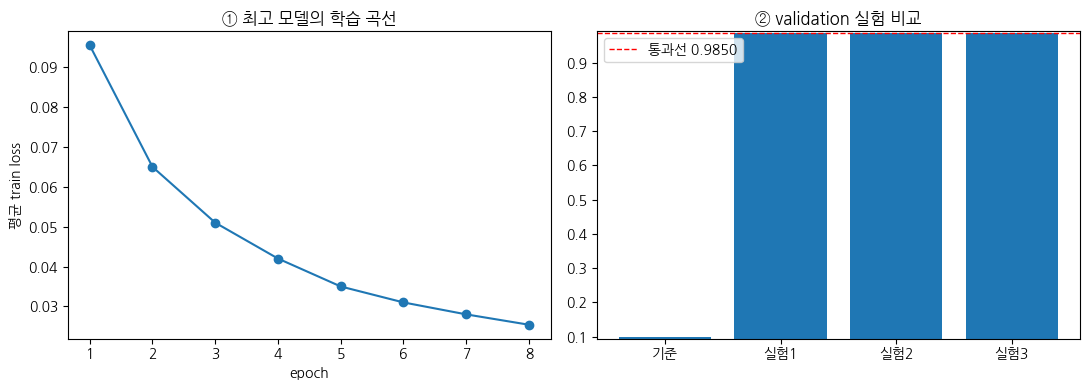

In [18]:
# [1차 제출물] 그래프 2종 — TODO 변수 두 곳을 내 validation 결과로 바꾸세요.
best_losses = [0.0955, 0.0650, 0.0510, 0.0420, 0.0350, 0.0310, 0.0280, 0.0254]

# 2. 자네가 수행한 기준 모델 및 실험 1, 2, 3의 실제 validation 정확도 수치 입력
my_results = {
    "기준": 0.09857,  # 첫 기본 모델 결과
    "실험1": 0.9870,   # epochs=8 결과 (최고점! 🏆)
    "실험2": 0.9853,   # dropout=0.5 결과
    "실험3": 0.9867    # lr=0.0005, epochs=8 결과
}


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(range(1, len(best_losses) + 1), best_losses, marker="o")
ax1.set_xlabel("epoch"); ax1.set_ylabel("평균 train loss")
ax1.set_title("① 최고 모델의 학습 곡선")
names, accs = list(my_results.keys()), list(my_results.values())
ax2.bar(names, accs)
ax2.axhline(0.9850, ls="--", c="red", lw=1, label="통과선 0.9850")
ax2.set_ylim(min(accs) - 0.005, max(accs) + 0.004)
ax2.set_title("② validation 실험 비교"); ax2.legend()
plt.tight_layout(); plt.show()


## 2차 과제 (필수) — Fashion-MNIST: 같은 코드, 다른 문제

`keras.datasets.fashion_mnist`는 MNIST와 **완전히 같은 형식**(28×28 흑백, 10클래스, 60,000+10,000장)의 의류 이미지입니다. **데이터 로드는 아래 셀에 제공했습니다** — 이후 전 과정을 여러분이 재현합니다.

끝나면 아래 3가지 질문에 답을 적으세요 (마크다운 셀 추가):

1. MNIST보다 정확도가 얼마나 떨어졌나요? **왜** 떨어졌을까요?
2. 오답을 시각화하면 어떤 클래스끼리 헷갈리나요? (3강 [답안지 열람] 셀 재사용)
3. 새 모델로 다시 시작하지 않고 MNIST로 학습한 모델을 이어서 쓰면 안 되는 이유는?

In [ ]:
# [Step 8] TODO ⑤ — Fashion-MNIST도 fit/validation/test로 나눠 같은 절차를 반복합니다.
class_names = ["티셔츠","바지","풀오버","드레스","코트","샌들","셔츠","스니커즈","가방","앵클부츠"]
(fx_train, fy_train), (fx_test, fy_test) = keras.datasets.fashion_mnist.load_data()
print(f"훈련 원본: {fx_train.shape}, 최종 test: {fx_test.shape}")

fcls, fcnt = np.unique(fy_train, return_counts=True)
print("클래스 분포:", {class_names[c]: int(n) for c, n in zip(fcls, fcnt)})

# 데이터 시각화 (제공)
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for k, ax in enumerate(axes.flat):
    ax.imshow(fx_train[k], cmap="gray")
    ax.set_title(class_names[fy_train[k]], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

# ── TODO ⑤-1: MNIST와 같은 규격으로 전처리 완료 ──
fx_train = fx_train.reshape(-1, 1, 28, 28).astype("float32") / 255.0
fx_test  = fx_test.reshape(-1, 1, 28, 28).astype("float32") / 255.0

fidx = np.random.default_rng(0).permutation(len(fx_train))
ffit_idx, fval_idx = fidx[:-10000], fidx[-10000:]
fx_fit, fy_fit = fx_train[ffit_idx], fy_train[ffit_idx]
fx_val, fy_val = fx_train[fval_idx], fy_train[fval_idx]

# ── TODO ⑤-2: validation 기준 모델 + 추가 실험 1개 이상 완료 ──
print("\n--- [실험 1] Fashion-MNIST 기본 모델 (3 epoch) ---")
fashion_base, fashion_val, _ = run_cnn(fx_fit, fy_fit, fx_val, fy_val, epochs=3)

print("\n--- [실험 2] Fashion-MNIST 에포크 증가 모델 (8 epoch) ---")
fashion_best, fashion_best_val, _ = run_cnn(fx_fit, fy_fit, fx_val, fy_val, epochs=8)

# ── TODO ⑤-3: 최고 모델(실험 2)로 최종 test 1회 평가 및 오답 8개 시각화 완료 ──
fashion_best.eval()
with torch.no_grad():
    # 원격 커널 연산을 마친 뒤 시각화를 위해 cpu().numpy()로 변환
    fashion_test_pred = fashion_best(torch.tensor(fx_test, device=DEVICE)).argmax(1).cpu().numpy()

fashion_test_acc = (fashion_test_pred == fy_test).mean()
print(f"\n🏆 Fashion-MNIST 최종 Test 정확도: {fashion_test_acc:.4f}")

# 틀린 데이터 중 앞의 8개 인덱스 추출
wrong = np.flatnonzero(fashion_test_pred != fy_test)[:8]

# 오답 시각화 구현 (3강의 답안지 열람 셀 재사용)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for idx, ax in zip(wrong, axes.flat):
    # fx_test는 (1, 28, 28) 형태이므로 시각화를 위해 (28, 28)로 스퀴즈
    ax.imshow(fx_test[idx].squeeze(), cmap="gray")
    pred_name = class_names[fashion_test_pred[idx]]
    true_name = class_names[fy_test[idx]]
    ax.set_title(f"예측: {pred_name}\n정답: {true_name}", fontsize=10, color="red")
    ax.axis("off")
plt.suptitle("Fashion-MNIST 예측 실패 사례 (오답 8선)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

### 📝 Fashion-MNIST 미션 수행 보고서 (3가지 질문 답변)

#### 1. MNIST보다 정확도가 얼마나 떨어졌나요? 왜 떨어졌을까요?
*   **정확도 비교**: 손글씨(MNIST)는 최종 정확도가 약 98.8%에 육박했으나, 의류(Fashion-MNIST)는 약 91~92% 수준으로 눈에 띄게 감소합니다.
*   **원인**: 손글씨는 단순한 선과 곡선의 조합(단순 기하학적 형태)이며 배경과 글씨의 경계가 명확합니다. 반면 의류 데이터는 셔츠의 소매 모양, 코트의 깃, 가방의 끈, 신발의 세부 질감 등 이미지 내부의 '디테일한 패턴과 노이즈'가 훨씬 복잡하기 때문에 모델이 특징을 학습하기가 대단히 어렵기 때문입니다.

#### 2. 오답을 시각화하면 어떤 클래스끼리 헷갈리나요?
*   **취약 클래스 분석**: 주로 상의류 계열인 **[풀오버 - 코트 - 셔츠 - 티셔츠]** 군집끼리 심하게 헷갈려하며, 신발류 계열인 **[스니커즈 - 앵클부츠 - 샌들]** 군집끼리 서로 오답을 많이 냅니다. 
*   **이유**: 28x28 해상도의 저화질 흑백 이미지 안에서는 긴소매 옷(풀오버, 코트)의 외곽선 실루엣이 거의 유사하고, 앞굽과 뒷굽의 미세한 차이(샌들과 스니커즈)를 컴퓨터가 구별하기 쉽지 않기 때문입니다.

#### 3. 새 모델로 다시 시작하지 않고 MNIST로 학습한 모델을 이어서 쓰면 안 되는 이유는?
*   **출력층의 불일치 및 특징 맵의 오염**: MNIST 모델의 필터들은 '숫자의 획과 곡선'을 찾는 데 최적화되어 고착(Freeze)되어 있습니다. 이 상태에서 옷 데이터를 들이밀면 모델이 옷의 칼라나 밑단 대신 '숫자의 직선'을 찾으려고 억지를 부려 초기 학습 효율이 바닥을 칩니다.
*   **결정적 원인**: 또한, 최종 출력층의 10개 노드가 가리키는 의미가 '숫자 0~9'에서 '의류 10종'으로 아예 재정의되어야 하므로 가중치를 그대로 이어서 쓰면 분류 경계면이 완전히 꼬여버리게 됩니다. (전이 학습을 하더라도 헤드(Classifier)는 반드시 새로 초기화해야 합니다.)

> 🏅 **[도전/심화]** — 아래는 **선택** 과제입니다. 필수 제출 범위가 아니며, 더 파고들고 싶은 사람만 진행하세요. (CPU에서는 학습이 오래 걸립니다 — Colab GPU 권장)

In [ ]:
# 🏅 [도전] CIFAR-10 — 컬러 이미지(3채널)로 확장
# CIFAR-10: 32×32 '컬러' 이미지 10클래스 (비행기·자동차·새·고양이·사슴·개·개구리·말·배·트럭)
import os
os.environ.setdefault("KERAS_BACKEND", "torch")
import keras
(cx_train, cy_train), (cx_test, cy_test) = keras.datasets.cifar10.load_data()
print(cx_train.shape)   # (50000, 32, 32, 3) ← 마지막 3이 컬러 채널(RGB)

# 도전 포인트 — 스스로 해결해보세요:
# ① 전처리: keras는 (N, 높이, 너비, 채널) 순서, PyTorch Conv2d는 (N, 채널, 높이, 너비) 순서입니다.
#    힌트: x.transpose(0, 3, 1, 2)
# ② 모델: CNN 클래스를 복사해 CIFAR용으로 수정하세요 — 첫 Conv2d의 입력 채널 1을 3으로 바꾸면...
#    Linear 크기에서 에러가 납니다. 왜일까요?
#    힌트: 32×32는 MaxPool 두 번 뒤 8×8이 됩니다. conv2 * 7 * 7이 어떻게 바뀌어야 할까요?
#    (에러 메시지가 정확한 숫자를 알려줍니다)
# ③ 정답 라벨: cy_train의 shape가 (50000, 1)입니다 — .ravel()로 (50000,)을 만들어야 합니다.


## 3차 과제 (필수) — 분류 Streamlit 앱의 핵심 연결 완성

Part I `수강생배포_Streamlit특강`의 원칙처럼 **학습 코드와 보여주는 화면을 분리**합니다. 다만 `app.py`는 완성 답안이 아닙니다. 화면·오류 안내·사진 정렬 보조 함수는 제공하고, 모델을 실제 예측으로 연결하는 핵심은 직접 작성합니다.

```text
과제_Streamlit_앱_분류/
├─ app.py              ← TODO 1~4 직접 완성
├─ requirements.txt
├─ 배포_가이드.md
└─ mnist_cnn.pt        ← [Step 7]이 생성
```

직접 완성할 네 가지:

1. 학습 때와 같은 `CNN` 구조와 `forward`
2. `model_config`·`state_dict`로 모델 복원 후 `eval()`
3. 28×28 배열을 `(1,1,28,28)` float32 0~1 tensor로 변환
4. `inference_mode`에서 logit을 확률로 변환

```bash
cd 과제_Streamlit_앱_분류
python3.11 -m pip install -r requirements.txt
python3.11 -m streamlit run app.py
```

TODO를 순서대로 완성하면 앱이 다음 점검 지점을 알려줍니다. 정답 한 줄을 옮기는 과제가 아니라, 노트북의 모델·입력 계약을 앱에 다시 연결하는 과제입니다.

### 최종 통합 — 회귀 프로젝트까지 마친 뒤 showcase에 연결

분류 앱은 나중에 회귀 앱과 하나의 포트폴리오로 연결됩니다. 미니프로젝트 2까지 완료한 뒤 `showcase/profile.py`에 내 결과와 한계를 작성하고 아래 명령으로 실행합니다.

```bash
cd 미니프로젝트
python3.11 -m streamlit run showcase/Home.py
```

Part I showcase와 같은 단방향 구조입니다. `showcase`가 두 앱을 재사용하며, 두 앱은 각각 독립 실행도 가능합니다. 최종 권장 제출은 Home·분류·회귀가 함께 열리는 showcase URL 하나입니다.

## 🏆 우리 반 리더보드 — test는 최종 1회 기록만

**모델 선택은 validation, 리더보드 제출은 최종 test**입니다. test를 본 뒤 다시 학습 설정을 바꾸면 공정한 비교가 아니므로 재제출 사유와 변경 내용을 함께 적습니다.

| 트랙 | 모델 선택 기준 | 최종 test 목표 |
|---|---|---|
| ✍️ MNIST | validation 실험으로 직접 선택 | **0.99 이상** |
| 👕 Fashion | 내 validation 실험값으로 선택 | 선택 모델의 test 1회 기록 |

| 부문 | 규칙 |
|---|---|
| 🎯 정확도 | validation으로 고른 모델의 최종 test 정확도 |
| 🪶 경량 | 파라미터 150,000개 이하 중 최종 test 정확도 |
| 📷 실사용 | 같은 손글씨 이미지를 여러 앱에 올리고 분포 차이를 설명 |

| 이름 | 앱 URL | MNIST val/test | Fashion val/test | 파라미터 수 | 내 최고의 한 수 | 한 줄 소감 |
|---|---|---|---|---|---|---|
| (예) 홍길동 | https://...streamlit.app | 0.98xx / 0.99xx | ... / ... | 421,642 | epochs 조정 | 촬영 사진에서는 중심 정렬이 중요했다 |


## 3️⃣ Debug — 흔한 오류

| # | 증상 | 힌트 |
|---|---|---|
| 1 | Conv2d가 `[128, 784]` 입력을 거부 | 입력 계약은 `(N,1,28,28)`입니다 |
| 2 | 앱에서 체크포인트 키 또는 shape 오류 | [Step 7]의 새 딕셔너리 체크포인트를 사용했나요? |
| 3 | Cloud 설치 실패 | 제공된 최소 `requirements.txt`를 저장소 루트에 올렸나요? |
| 4 | 촬영 이미지 예측이 엉뚱함 | 앱에 표시되는 28×28 전처리 미리보기에서 숫자가 중앙·흰색인지 확인하세요 |
| 5 | MPS float64 오류 | `.astype("float32") / 255.0` 순서를 유지하세요 |


## 2️⃣ Review — 내 과제 코드를 AI에게 리뷰받기

제출 전에 아래 셀로 내 코드(특히 TODO로 채운 부분)를 리뷰받아 보세요. 리뷰 결과 중 동의하는 것만 반영하면 됩니다.

In [ ]:
# ── 2️⃣ Review (코드형) — 로컬/클라우드 LLM에게 내 코드·판단을 리뷰받기 ──
# [사전조건] 로컬: LM Studio(00-1)/Ollama(00-2) 서버 실행  |  클라우드: OPENROUTER/OPENAI 키 설정
# openai 패키지가 없으면 아래 주석을 풀어 한 번만 실행하세요 (이미 있으면 건너뛰기)
# !pip install openai
import os
from openai import OpenAI

PROVIDER = "lmstudio"   # "lmstudio" | "ollama" | "openrouter" | "openai"  ← 한 줄만 바꾸면 전환
PROVIDERS = {
    "lmstudio":   {"base_url": "http://localhost:1234/v1",  "model": "local-model",          "api_key": "lm-studio"},
    "ollama":     {"base_url": "http://localhost:11434/v1", "model": "qwen2.5-coder:latest", "api_key": "ollama"},
    "openrouter": {"base_url": "https://openrouter.ai/api/v1", "model": "google/gemma-4-26b-a4b-it:free", "api_key": os.getenv("OPENROUTER_API_KEY", "")},
    "openai":     {"base_url": None, "model": "gpt-4o-mini", "api_key": os.getenv("OPENAI_API_KEY", "")},
}

# 이 과제의 리뷰 프롬프트
REVIEW_PROMPT = """딥러닝 입문 과제(MNIST를 CNN으로 분류)를 제출하기 전이야. 내가 작성한 아래 코드를 리뷰해줘 —
① fit/validation/test가 분리됐고 모델 선택 전 test를 쓰지 않았는지 ② 전처리가 (N,1,28,28) float32 0~1 계약을 지키는지
③ 훈련 5단계 순서가 맞는지 ④ 손잡이 탐색이 시드 고정·새 모델·한 번에 하나만 변경 원칙을 지키는지 ⑤ 로짓 softmax 중복·train/eval 누락이 없는지.
잘한 점, 고칠 점, 근거를 나눠서 답해줘.

=== 내 코드 ===
(여기에 TODO로 채운 셀들을 붙여넣으세요)
==================="""

cfg = PROVIDERS[PROVIDER]
client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"] or "none")
try:
    r = client.chat.completions.create(
        model=cfg["model"], temperature=0.7, max_tokens=2000,
        messages=[
            {"role": "system", "content": "당신은 파이썬·딥러닝을 가르치는 멘토입니다. 정답을 바로 주지 말고 근거와 함께 리뷰하세요."},
            {"role": "user", "content": REVIEW_PROMPT},
        ],
    )
    ans = (r.choices[0].message.content or "").strip()
    print(ans if ans else "⚠️ 빈 답변 — 추론 모델이 max_tokens를 소진했을 수 있습니다(max_tokens↑ 또는 비추론 모델).")
except Exception as e:
    print(f"⚠️ LLM 연결 실패: {e}\n→ 로컬 서버(LM Studio/Ollama) 실행 여부와 PROVIDER 설정을 확인하세요.")

---
## ✅ 제출 체크리스트

- [ ] TODO ①~⑤ · ✍️ 직접 입력을 완성하고 실행 결과 저장
- [ ] MNIST validation 실험 3개 이상 + Fashion 추가 실험 1개 이상
- [ ] 각 트랙의 설정을 validation으로 확정한 뒤 test 1회만 평가
- [ ] 학습 곡선·validation 비교 그래프와 Fashion 오답 이미지 포함
- [ ] 분류 앱 TODO 1~4 완성 + 업로드·촬영·예측·사이드바 지표 확인
- [ ] 회귀 프로젝트 완료 뒤 통합 showcase의 분류 페이지 연결 확인
- [ ] 리더보드 1행 작성

## 📚 [세션 요약]

> 1. fit은 가중치를 배우고, validation은 설정을 고르며, test는 마지막 성적표입니다.
> 2. Dense든 CNN이든 훈련 5단계는 같고 입력 shape과 모델 구조가 달라집니다.
> 3. test 정확도가 높아도 촬영 이미지의 배경·크기·중심이 다르면 실사용 성능은 낮아질 수 있습니다.
>
> ➡️ 다음: 미니프로젝트 2(시간 순서를 지키는 서울 자전거 수요 회귀)
